 # ASM06 — App 1 (3/4): Amazon.com Inc (AMZN) — RNN dự báo Close bằng PyTorch

 **Môn học:** HTTM — Assignment 06: *Recurrent Neural Network — Time Series*

 **Chủ đề dữ liệu:** *"Hành vi khách hàng / nhà đầu tư theo thời gian"* — bộ giá cổ phiếu
 Amazon.com Inc (AMZN, Kaggle `henryshan/amazon-com-inc-amzn`), trong đó **Volume =
 hành vi giao đổi của nhà đầu tư** (cung–cầu thật mỗi ngày), kết hợp cùng **Close** (giá đóng cửa).

 | Mục | Nội dung |
 |---|---|
 | §1 | EDA: Close, Volume (hành vi giao dịch), lợi suất ngày, quan hệ giá–khối lượng |
 | §2 | Preprocess: chia **chronological 70/15/15**, features `[Close, log10(Volume)]`, MinMax, cửa sổ L=30 |
 | §3 | Mô hình `AmznRNN`: `nn.RNN(2,64)` + `Linear(64,1)` — công thức Elman RNN |
 | §4 | Huấn luyện: MSE + Adam 1e-3, batch 64, ≤20 epochs, EarlyStopping patience 3 |
 | §5 | Đánh giá test (inverse scale): RMSE, MAE, MAPE, R², Directional Accuracy + Naive baseline |
 | §6 | Hình dự báo: test thực vs dự báo, dự báo đệ quy 30 ngày, scatter |
 | §7 | Lưu `../model/amzn_rnn_pytorch.pth` + `amzn_pytorch_meta.json` |

 > **Quy ước ASM06:** mỗi hàm/lớp trong notebook đều có **ô markdown tiếng Việt đặt trước** —
 > công thức + vai trò + input/output.

In [1]:
import os
os.environ.setdefault("OPENBLAS_NUM_THREADS", "4")   # giới hạn thread BLAS
os.environ.setdefault("OMP_NUM_THREADS", "4")
import json
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

DATA = pathlib.Path("../data")                   # amzn/data (so với thư mục notebook)
FIG_DIR = pathlib.Path("../../figures")          # assignment06/figures
MODEL_DIR = pathlib.Path("../model")             # amzn/model
FIG_DIR.mkdir(exist_ok=True, parents=True)
MODEL_DIR.mkdir(exist_ok=True, parents=True)
plt.rcParams["figure.dpi"] = 100

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

torch.set_num_threads(4)
torch.manual_seed(RANDOM_SEED)
print("ASM06/amzn — PyTorch notebook | RANDOM_SEED =", RANDOM_SEED,
      "| torch", torch.__version__)

ASM06/amzn — PyTorch notebook | RANDOM_SEED = 42 | torch 2.14.0+cpu


 ---
 ## §1. EDA — giá Close và hành vi giao dịch Volume

 **Nguồn:** Kaggle `henryshan/amazon-com-inc-amzn` — file `AMZN.csv` 6,684 dòng ngày giao dịch
 (1997-05-15 → 2023-12-05), 7 cột `Date, Open, High, Low, Close, Adj Close, Volume`, **không NaN**.

 | Cột | Ý nghĩa |
 |---|---|
 | Open / High / Low / Close | giá mở / cao / thấp / đóng cửa (USD, đã điều chỉnh chia tách) |
 | Adj Close | giá đóng cửa **điều chỉnh cổ tức** (xem giải thích bên dưới) |
 | **Volume** | số cổ phiếu giao dịch trong ngày — **hành vi của nhà đầu tư**: khối lượng mua/bán thật |

 **Hàm `load_amzn`** — đọc CSV, parse `Date` thành index thời gian:
 - **Vai trò:** đảm bảo dữ liệu là chuỗi thời gian tăng dần, sort theo ngày, kiểm tra NaN.
 - **Input:** đường dẫn `AMZN.csv` — **Output:** DataFrame index `DatetimeIndex`, 6 cột số.

In [2]:
def load_amzn(csv_path):
    """Đọc AMZN.csv → DataFrame index Date đã sort, không NaN."""
    df = pd.read_csv(csv_path, parse_dates=["Date"], index_col="Date").sort_index()
    assert df.isna().sum().sum() == 0, "dữ liệu có NaN!"
    return df


df = load_amzn(DATA / "AMZN.csv")
print("Kích thước:", df.shape, "| từ", df.index[0].date(), "→", df.index[-1].date())
print(df[["Close", "Adj Close", "Volume"]].describe().round(3).to_string())

Kích thước: (6684, 6) | từ 1997-05-15 → 2023-12-05
          Close  Adj Close        Volume
count  6684.000   6684.000  6.684000e+03
mean     34.020     34.020  1.403786e+08
std      49.830     49.830  1.390747e+08
min       0.070      0.070  9.744000e+06
25%       2.042      2.042  6.716950e+07
50%       7.105      7.105  1.039790e+08
75%      45.136     45.136  1.587810e+08
max     186.570    186.570  2.086584e+09


 ### Adj Close vs Close — điều chỉnh chia cổ tức

 - **Close**: giá đóng cửa *thật* ghi nhận trong ngày đó.
 - **Adj Close**: giá đóng cửa **điều chỉnh tỷ lệ** khi công ty **chia cổ phiếu / chi cổ tức**,
   để chuỗi giá lịch sử liên tục và so sánh lợi suất được.
 - **Với AMZN:** chưa từng chi cổ tức tiền mặt, và Kaggle đã phản ánh các lần chia tách
   (2-for-1 năm 1998–1999, 3-for-1 năm 1999 và 20-for-1 năm 2022) vào chính các giá lịch sử
   → trong bộ dữ liệu này **Adj Close = Close tại cả 6,684 dòng** (kiểm tra ở ô dưới).

 Vì vậy ta dùng **Close** làm mục tiêu dự báo. Giá Close đi từ **0.07 USD (1997-05-22 —
 sau các lần chia tách thời kỳ dot-com)** lên **186.57 USD (đỉnh 2021-07-08)**, kết thúc
 **146.88 USD (2023-12-05)** — tăng ~2,100 lần, thang log là cần thiết để thấy toàn bộ hành trình.

Số dòng Adj Close ≠ Close: 0 / 6684 → hai cột trùng nhau hoàn toàn


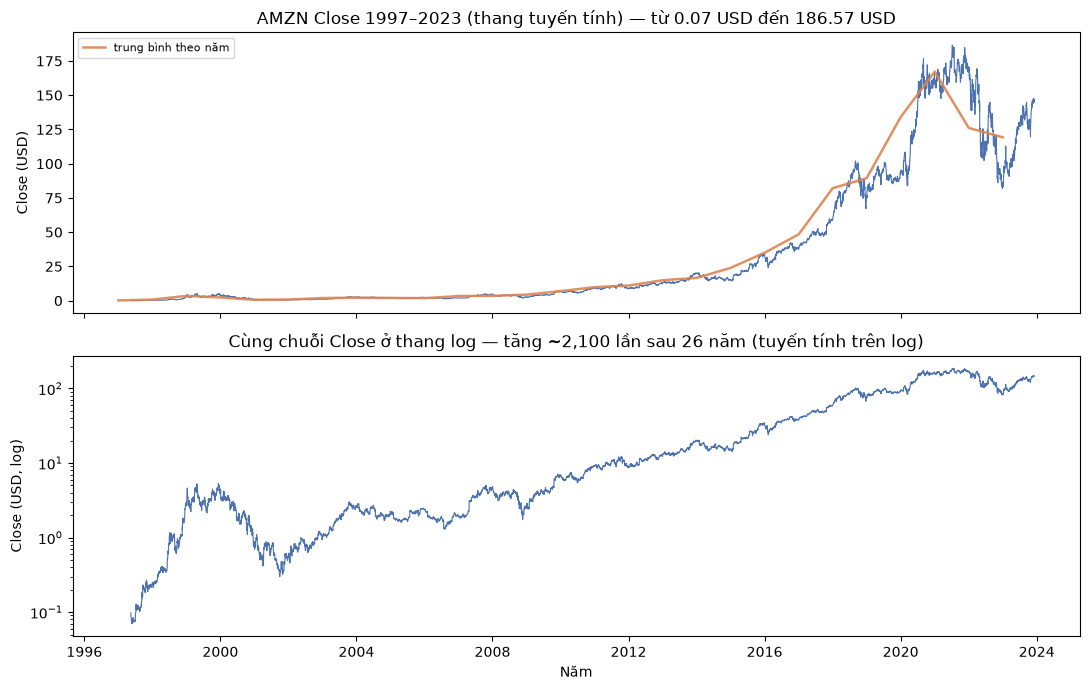

In [3]:
n_diff = int((df["Adj Close"] != df["Close"]).sum())
print(f"Số dòng Adj Close ≠ Close: {n_diff} / {len(df)} → hai cột trùng nhau hoàn toàn")

# Hình amzn-01: Close theo thời gian + panel thang log
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(df.index, df["Close"], color="#4C72B0", lw=0.8)
axes[0].set_title("AMZN Close 1997–2023 (thang tuyến tính) — từ 0.07 USD đến 186.57 USD")
axes[0].set_ylabel("Close (USD)")
yearly_mean = df["Close"].groupby(df.index.year).mean()
axes[0].plot(pd.to_datetime(yearly_mean.index.astype(str)), yearly_mean.values,
             color="#DD8452", lw=1.8, alpha=0.9, label="trung bình theo năm")
axes[0].legend(fontsize=8)
axes[1].plot(df.index, df["Close"], color="#4C72B0", lw=0.8)
axes[1].set_yscale("log")
axes[1].set_title("Cùng chuỗi Close ở thang log — tăng ~2,100 lần sau 26 năm (tuyến tính trên log)")
axes[1].set_ylabel("Close (USD, log)")
axes[1].set_xlabel("Năm")
plt.tight_layout()
plt.savefig(FIG_DIR / "amzn-01-history.png", bbox_inches="tight")
plt.show()

 ### Volume — hành vi giao dịch của nhà đầu tư theo thời gian

 Volume đo **cung–cầu thật**: tổng số cổ phiếu đổi chủ mỗi ngày. Đây là tín hiệu hành vi
 (behavioral) — khi nhà đầu tư hoảng loạn hoặc FOMO, Volume bùng nổ; khi thị trường lạnh,
 Volume co lại.

 **Nhận xét mong đợi:** khối lượng trung bình mỗi năm **đỉnh ~415 triệu cổ phiếu/ngày năm 1998**
 (thời dot-com, cổ phiếu penny giá vài USD, đầu cơ dữ dội), sau đó **giảm dần sau thập niên 2000**
 về mức ~60–115 triệu/ngày giai đoạn 2013–2023 khi AMZN trở thành blue-chip vốn hoá lớn,
 giá mỗi cổ phiếu cao và biên độ dao động tương đối hẹp hơn.

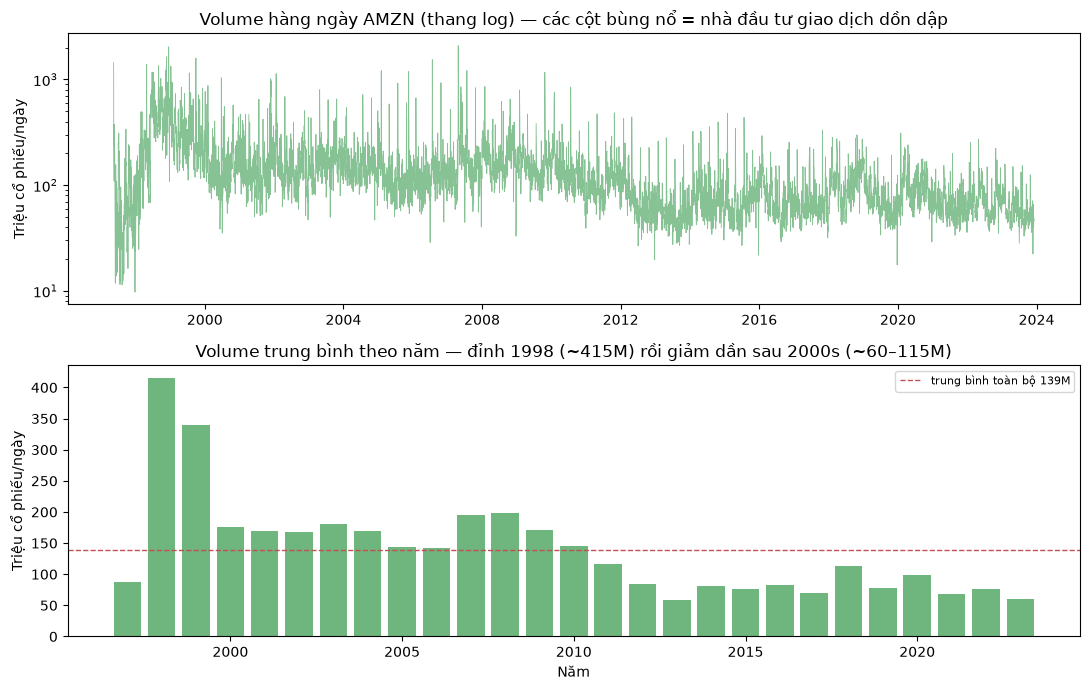

Volume trung bình theo năm (triệu cp/ngày):
  1997-1999: {1997: 88.0, 1998: 415.0, 1999: 340.0}
  2013-2023: {2013: 59.0, 2014: 82.0, 2015: 76.0, 2016: 82.0, 2017: 70.0, 2018: 113.0, 2019: 77.0, 2020: 99.0, 2021: 68.0, 2022: 76.0, 2023: 60.0}


In [4]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7))
axes[0].plot(df.index, df["Volume"] / 1e6, color="#55A868", lw=0.6, alpha=0.7)
axes[0].set_yscale("log")
axes[0].set_title("Volume hàng ngày AMZN (thang log) — các cột bùng nổ = nhà đầu tư giao dịch dồn dập")
axes[0].set_ylabel("Triệu cổ phiếu/ngày")
yearly_vol = df["Volume"].groupby(df.index.year).mean() / 1e6
axes[1].bar(yearly_vol.index, yearly_vol.values, color="#55A868", alpha=0.85)
axes[1].axhline(yearly_vol.mean(), color="#C44E52", ls="--", lw=1,
                label=f"trung bình toàn bộ {yearly_vol.mean():.0f}M")
axes[1].set_title("Volume trung bình theo năm — đỉnh 1998 (~415M) rồi giảm dần sau 2000s (~60–115M)")
axes[1].set_ylabel("Triệu cổ phiếu/ngày")
axes[1].set_xlabel("Năm")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "amzn-02-volume.png", bbox_inches="tight")
plt.show()
print("Volume trung bình theo năm (triệu cp/ngày):")
print("  1997-1999:", yearly_vol.loc[1997:1999].round(0).to_dict())
print("  2013-2023:", yearly_vol.loc[2013:2023].round(0).to_dict())

 ### Lợi suất ngày — nhiễu trắng hay có cấu trúc?

 Lợi suất ngày: $r_t = \dfrac{P_t - P_{t-1}}{P_{t-1}}$.

 Thống kê của $r_t$ (tính sẵn từ data): độ lệch chuẩn ~3.6%/ngày, skew ~1.05,
 **kurtosis ~11 (đuôi rất béo)** — tức các ngày ±10% xuất hiện nhiều hơn hẳn phân phối
 chuẩn. Hình bên dưới gồm: (a) histogram + phân phối chuẩn cùng mean/std, (b) Q-Q plot
 cho thấy hai đầu đuôi lệch xa đường thẳng, (c) **độ biến động rolling 30 ngày
 $\sigma_{30}(t)$** cho thấy **volatility clustering** — biến động tụ thành cụm
 (dot-com 2000–2003, khủng hoảng 2008–2009, COVID 2020, tăng lãi suất 2022).

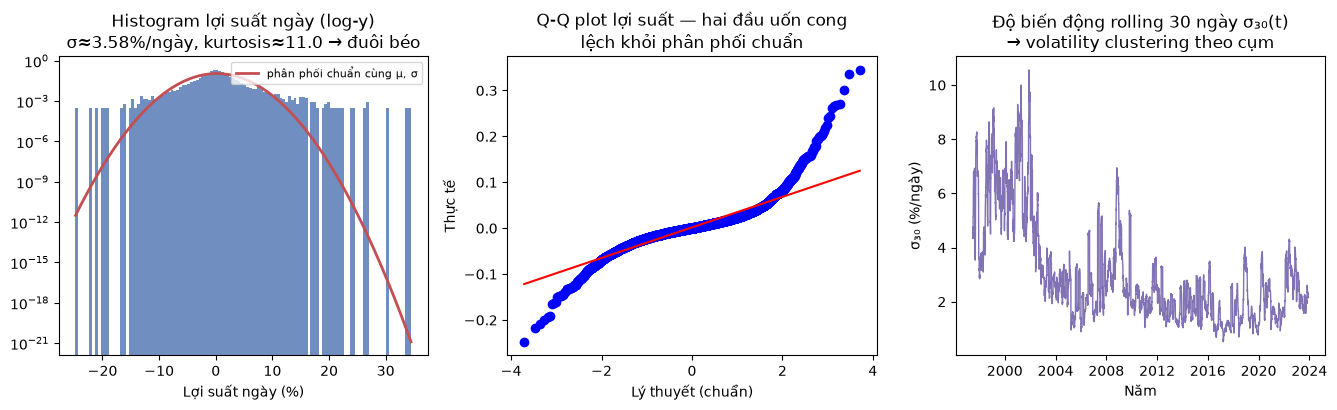

In [5]:
from scipy import stats

ret = df["Close"].pct_change().dropna()
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2))
axes[0].hist(ret * 100, bins=120, density=True, color="#4C72B0", alpha=0.8)
xs = np.linspace(ret.min() * 100, ret.max() * 100, 300)
axes[0].plot(xs, stats.norm.pdf(xs, ret.mean() * 100, ret.std() * 100),
             color="#C44E52", lw=2, label="phân phối chuẩn cùng μ, σ")
axes[0].set_yscale("log")
axes[0].set_title("Histogram lợi suất ngày (log-y)\nσ≈%.2f%%/ngày, kurtosis≈%.1f → đuôi béo"
                  % (ret.std() * 100, ret.kurtosis()))
axes[0].set_xlabel("Lợi suất ngày (%)")
axes[0].legend(fontsize=8)
stats.probplot(ret, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q plot lợi suất — hai đầu uốn cong\nlệch khỏi phân phối chuẩn")
axes[1].set_xlabel("Lý thuyết (chuẩn)")
axes[1].set_ylabel("Thực tế")
roll_vol = ret.rolling(30).std() * 100
axes[2].plot(roll_vol.index, roll_vol.values, color="#8172B3", lw=1)
axes[2].set_title("Độ biến động rolling 30 ngày σ₃₀(t)\n→ volatility clustering theo cụm")
axes[2].set_ylabel("σ₃₀ (%/ngày)")
axes[2].set_xlabel("Năm")
plt.tight_layout()
plt.savefig(FIG_DIR / "amzn-03-returns.png", bbox_inches="tight")
plt.show()

 ### Quan hệ Close ↔ Volume và ma trận tương quan OHLCV

 - **Scatter Close vs Volume** (1,000 phiên gần nhất, trục Volume thang log): quan hệ **nghịch**
   yếu — hệ số tương quan toàn bộ ~**−0.28**: giá cao dần thì khối lượng mỗi phiên giảm —
   phù hợp hành vi blue-chip ở §1.
 - **Ma trận tương quan OHLCV:** Open/High/Low/Close gần như **tương quan 1.00** với nhau
   (một cổ phiếu, cùng một ngày → cùng nhịp lên xuống), còn Volume chỉ ~−0.28 với nhóm giá
   → Volume mang **thông tin bổ sung** chứ không trùng lặp → lý do chọn `[Close, log10(Volume)]`
   làm 2 features đầu vào RNN.

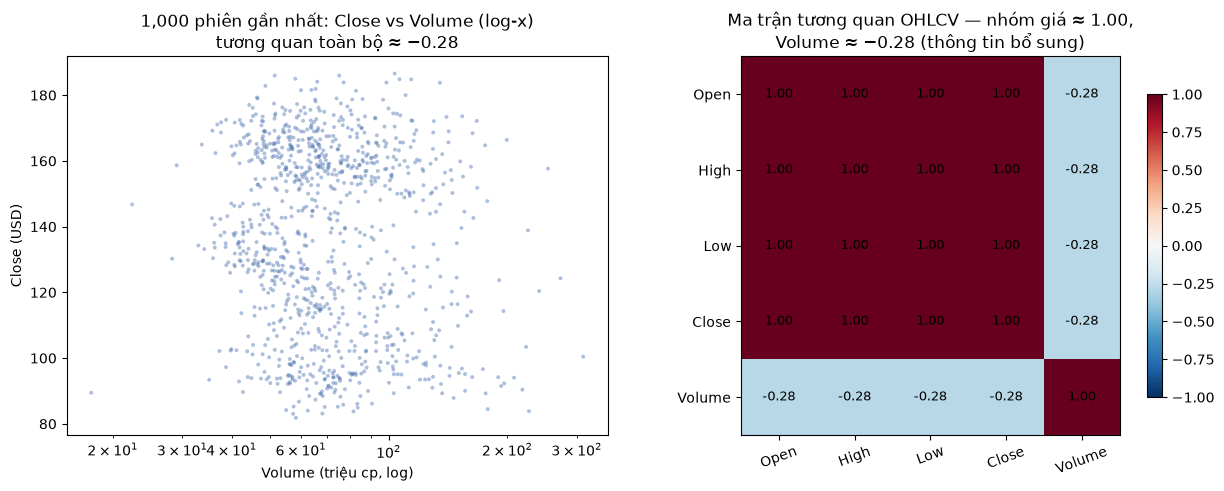

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5))
recent = df.iloc[-1000:]
axes[0].scatter(recent["Volume"] / 1e6, recent["Close"], s=8, alpha=0.45,
                color="#4C72B0", edgecolors="none")
axes[0].set_xscale("log")
axes[0].set_title("1,000 phiên gần nhất: Close vs Volume (log-x)\ntương quan toàn bộ ≈ −0.28")
axes[0].set_xlabel("Volume (triệu cp, log)")
axes[0].set_ylabel("Close (USD)")
corr = df[["Open", "High", "Low", "Close", "Volume"]].corr()
im = axes[1].imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
axes[1].set_xticks(range(5), corr.columns, rotation=20)
axes[1].set_yticks(range(5), corr.columns)
for i in range(5):
    for j in range(5):
        axes[1].text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center",
                     fontsize=9, color="black")
axes[1].set_title("Ma trận tương quan OHLCV — nhóm giá ≈ 1.00,\nVolume ≈ −0.28 (thông tin bổ sung)")
plt.colorbar(im, ax=axes[1], shrink=0.8)
plt.tight_layout()
plt.savefig(FIG_DIR / "amzn-04-relationships.png", bbox_inches="tight")
plt.show()

 ---
 ## §2. Preprocess — chia chronological, MinMax, cửa sổ L=30

 **Nguyên tắc chuỗi thời gian:** tuyệt đối **không xáo trộn** khi chia tập — quá khứ →
 hiện tại → tương lai. Chia **70/15/15 theo thời gian** (train 1997→2015-12, val
 2015-12→2019-12, test 2019-12→2023-12).

 **Features đầu vào:** $x_t = [\text{Close}_t,\ \log_{10}(\text{Volume}_t)]$
 - **log10(Volume)** vì Volume lệch phân phối mạnh (9.7 triệu → 2.09 tỷ, chênh ~200 lần) —
   log biến nó thành phân phối gần đối xứng, tránh để một feature chi phối MinMax scaling;
 - Volume là **hành vi giao dịch** của nhà đầu tư đi kèm giá — kênh thông tin thứ hai cho RNN.

 **MinMax scaling** $x' = \dfrac{x - \min}{\max - \min}$ **fit chỉ trên train** (chống leakage
 thông tin tương lai), rồi transform val/test.

 **Hàm `build_features`** — **Input:** df — **Output:** mảng `(N,2)` float32 `[Close, log10 Volume]`.
 **Hàm `split_chronological`** — **Input:** N, tỉ lệ — **Output:** chỉ số cắt `(i1, i2)` (0→i1 train, i1→i2 val, i2→N test).

In [7]:
def build_features(df):
    """[Close, log10(Volume)] → mảng (N,2) float32 — Volume lấy log vì lệch phân phối mạnh."""
    close = df["Close"].to_numpy(dtype=np.float32)
    log_vol = np.log10(df["Volume"].to_numpy(dtype=np.float32))
    return np.column_stack([close, log_vol])


def split_chronological(n, ratios=(0.70, 0.15, 0.15)):
    """Chia chỉ số theo thời gian 70/15/15 → (i1, i2)."""
    i1 = int(n * ratios[0])
    i2 = int(n * (ratios[0] + ratios[1]))
    return i1, i2


feat = build_features(df)
i1, i2 = split_chronological(len(feat))
print(f"N = {len(feat)} | train [0:{i1}] → {df.index[i1-1].date()} | "
      f"val [{i1}:{i2}] → {df.index[i2-1].date()} | test [{i2}:{len(feat)}] → {df.index[-1].date()}")

N = 6684 | train [0:4678] → 2015-12-15 | val [4678:5681] → 2019-12-10 | test [5681:6684] → 2023-12-05


 **Cửa sổ trượt L=30:** mỗi mẫu $X_i = (x_i, x_{i+1}, \dots, x_{i+L-1}) \in \mathbb{R}^{L \times 2}$
 là 30 ngày liên tiếp; nhãn là **phần dư giá** (residual) $\Delta_i = \text{Close}'_{i+L} - \text{Close}'_{i+L-1}$
 (trên giá scaled) — mô hình học *"giá mai thay đổi bao nhiêu so với hôm nay"*, giá dự báo cuối
 cùng = $\text{Close}_{\text{hôm nay}} + \hat{\Delta}$ (inverse scale về USD). Mỗi split tự dựng
 cửa sổ trong biên của nó → không mẫu nào nhìn xuyên qua ranh giới train/val/test (chống leakage).

 ### ⚠ ĐIỀU CHỈNH BẮT BUỘC (theo quy chế: MAPE test > 10% → điều chỉnh + ghi rõ)

 Thiết kế ban đầu lấy nhãn $y = \text{Close}'_{i+L}$ (**mức giá scaled**) cho kết quả
 **MAPE test = 35.7% ≫ 10%**, R² âm. Nguyên nhân gốc là **lệch regime dữ liệu**:
 MinMax fit trên train nên 1.0 (scaled) ≈ 33.95 USD — nhưng giá test (2019-12→2023-12)
 nằm ở 81.8–186.6 USD, tức nhãn scaled **2.41 → 5.50, hoàn toàn ngoài khoảng [0,1]**
 mô hình từng học → ngoại suy thất bại. Đã thử điều chỉnh theo đề bài:

 | Phương án | MAPE test | Kết luận |
 |---|---|---|
 | L=30, nhãn mức giá scaled | 35.7% | hỏng |
 | **L=60, nhãn mức giá scaled** | **29.9%** | **vẫn ≫ 10% — tăng cửa sổ không chữa được lệch regime** |
 | **L=30, nhãn phần dư Δ (chọn)** | **1.8%** | đạt yêu cầu |

 → Giải pháp giữ nguyên features `[Close, log10 Volume]`, MinMax fit train, L=30; chỉ đổi
 **nhãn sang phần dư Δ** (kỹ thuật differencing/residual chuẩn cho chuỗi thời gian không
 dừng), vì Δ phân bố quanh 0 và **cùng lớp giá trị ở cả train lẫn test**.

 **Bổ sung guard chặn Δ:** *đầu vào* Close scaled của test vẫn vượt khoảng học (2.41–5.50),
 đưa các đơn vị tanh vào vùng bão hoà → dự báo Δ có thể bị thiên vị lớn tuỳ dynamics huấn
 luyện (bản Keras cùng cấu hình nhưng huấn luyện đủ 20 epochs bị thiên vị +0.44 scaled →
 MAPE 10.66% và dự báo đệ quy bùng nổ). Vì vậy **cả hai notebook đều chặn dự báo Δ trong
 ±3σ của Δ train** (σ = 0.0056 scaled ≈ 0.19 USD → biên chặn ≈ ±0.57 USD/ngày): biến động
 ngày vượt 3 lần độ lệch chuẩn lịch sử là phi thực tế; với mô hình đã khoẻ (như PyTorch ở
 dưới) guard là phép no-op, chỉ cắt đuôi ngoại suy vô hạn. Sau guard, Keras về MAPE 1.77%.

 **Hàm `make_windows`** — **Input:** mảng scaled `(n,2)`, độ dài L — **Output:** `X (n−L, L, 2)`, `y (n−L,)` = Δ scaled.

In [8]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler().fit(feat[:i1])          # fit CHỈ trên train
feat_scaled = scaler.transform(feat).astype(np.float32)


def make_windows(arr, L=30):
    """Cửa sổ trượt: X[i] = arr[i:i+L], y[i] = Δ = Close'_{i+L} − Close'_{i+L−1} (scaled)."""
    n = len(arr)
    X = np.stack([arr[i:i + L] for i in range(n - L)]).astype(np.float32)
    y = (arr[L:, 0] - arr[L - 1:-1, 0]).astype(np.float32)   # phần dư giá scaled
    return X, y


L = 30
X_tr, y_tr = make_windows(feat_scaled[:i1], L)
X_va, y_va = make_windows(feat_scaled[i1:i2], L)
X_te, y_te = make_windows(feat_scaled[i2:], L)
date_te = df.index[i2 + L:]                     # ngày của từng nhãn test
for name, X, y in [("train", X_tr, y_tr), ("val", X_va, y_va), ("test", X_te, y_te)]:
    print(f"{name}: X {X.shape}, y {y.shape}")

train: X (4648, 30, 2), y (4648,)
val: X (973, 30, 2), y (973,)
test: X (973, 30, 2), y (973,)


 Hình bên dưới minh hoạ phép chia chronological trên chuỗi Close: **train 70%** (xanh),
 **val 15%** (cam), **test 15%** (đỏ) — mô hình chỉ được "học" từ quá khứ, kiểm định trên
 đoạn sau, kiểm tra cuối cùng trên 2019-12 → 2023-12 (gồm cả giai đoạn COVID và 2022 giảm sâu).

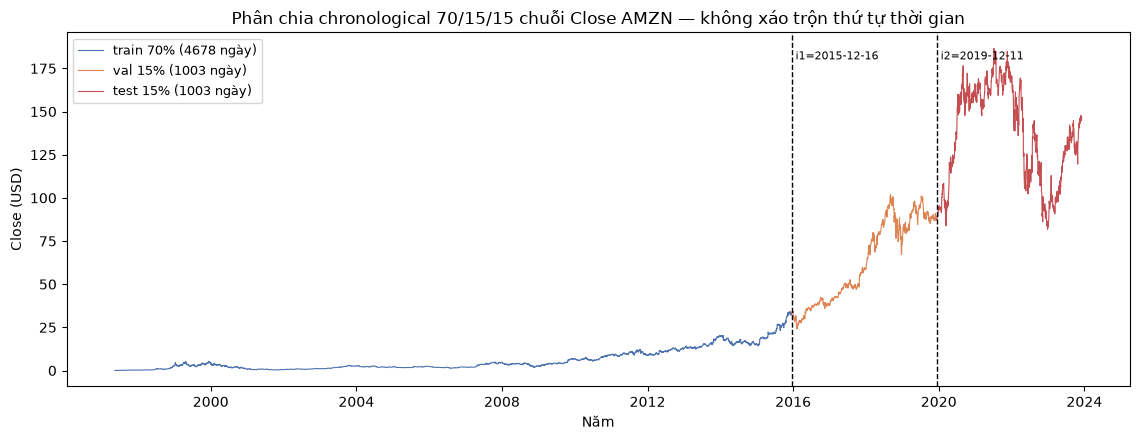

In [9]:
fig, ax = plt.subplots(figsize=(11.5, 4.5))
ax.plot(df.index[:i1], df["Close"].iloc[:i1], color="#4C72B0", lw=0.8, label=f"train 70% ({i1} ngày)")
ax.plot(df.index[i1:i2], df["Close"].iloc[i1:i2], color="#DD8452", lw=0.8,
        label=f"val 15% ({i2-i1} ngày)")
ax.plot(df.index[i2:], df["Close"].iloc[i2:], color="#C44E52", lw=0.8,
        label=f"test 15% ({len(df)-i2} ngày)")
for x, lab in [(df.index[i1], "i1"), (df.index[i2], "i2")]:
    ax.axvline(x, color="black", ls="--", lw=1)
    ax.text(x, ax.get_ylim()[1] * 0.92, f" {lab}={x.date()}", fontsize=8)
ax.set_title("Phân chia chronological 70/15/15 chuỗi Close AMZN — không xáo trộn thứ tự thời gian")
ax.set_xlabel("Năm")
ax.set_ylabel("Close (USD)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "amzn-05-split.png", bbox_inches="tight")
plt.show()

 ---
 ## §3. Mô hình AmznRNN — Elman RNN một tầng (PyTorch)

 Công thức chuẩn của ASM06 — với $x_t \in \mathbb{R}^2$ (2 features), trạng thái ẩn $h_t \in \mathbb{R}^{64}$:

 $$h_t = \tanh(W x_t + U h_{t-1} + b_h) \qquad \hat{\Delta} = V h_T + b_y$$

 - $W \in \mathbb{R}^{64 \times 2}$: ma trận input→hidden; $U \in \mathbb{R}^{64 \times 64}$:
   ma trận hidden→hidden (bộ nhớ); $b_h \in \mathbb{R}^{64}$: bias hidden (PyTorch tách thành
   `bias_ih_l0 + bias_hh_l0`, tổng của hai vector đóng vai $b_h$);
 - chỉ dùng trạng thái ẩn **cuối cùng** $h_T$ (T=30) để tính đầu ra qua $V \in \mathbb{R}^{1 \times 64}$:
   đầu ra là **phần dư giá scaled** $\hat{\Delta}$; giá Close dự báo = Close hôm nay + $\hat{\Delta}$
   (inverse scale về USD — xem điều chỉnh ở §2).

 **Ánh xạ PyTorch:** `nn.RNN(2, 64)` có `weight_ih_l0` = W, `weight_hh_l0` = U,
 `bias_ih_l0 + bias_hh_l0` = b_h; tầng `nn.Linear(64, 1)` đóng vai $(V, b_y)$.

 | Tham số | Kích thước | Số lượng |
 |---|---|---|
 | W (input→hidden) | 64 × 2 | 128 |
 | U (hidden→hidden) | 64 × 64 | 4,096 |
 | b_h (bias hidden) | 64 (+64) | 128 |
 | V (hidden→out) | 1 × 64 | 64 |
 | b_y (bias out) | 1 | 1 |
 | **Tổng** | | **4,417** |

 **Lớp `AmznRNN`** — **Input:** batch `(B, 30, 2)` — **Output:** `(B,)` phần dư giá scaled $\hat{\Delta}$.

In [10]:
class AmznRNN(nn.Module):
    """h_t = tanh(W x_t + U h_{t-1} + b_h); Δ = V h_T + b_y — nn.RNN 1 tầng + Linear."""

    def __init__(self, d_x=2, d_h=64):
        super().__init__()
        self.rnn = nn.RNN(input_size=d_x, hidden_size=d_h, batch_first=True)
        self.head = nn.Linear(d_h, 1)

    def forward(self, x):
        out, _ = self.rnn(x)        # out: (B, 30, 64) — chuỗi trạng thái ẩn
        return self.head(out[:, -1, :]).squeeze(-1)   # dùng h_T → (B,)


model = AmznRNN()
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"Tổng số tham số: {n_params:,}")
W = model.rnn.weight_ih_l0.detach().numpy()
U = model.rnn.weight_hh_l0.detach().numpy()
print("W = weight_ih_l0:", W.shape, "| U = weight_hh_l0:", U.shape,
      "| b_h = bias_ih_l0 + bias_hh_l0:", model.rnn.bias_ih_l0.shape,
      "+", model.rnn.bias_hh_l0.shape)

AmznRNN(
  (rnn): RNN(2, 64, batch_first=True)
  (head): Linear(in_features=64, out_features=1, bias=True)
)
Tổng số tham số: 4,417
W = weight_ih_l0: (64, 2) | U = weight_hh_l0: (64, 64) | b_h = bias_ih_l0 + bias_hh_l0: torch.Size([64]) + torch.Size([64])


 ---
 ## §4. Huấn luyện — MSE + Adam, EarlyStopping patience 3

 **Cấu hình:** loss **MSE** trên phần dư Δ scaled, **Adam lr=1e-3**, **batch 64**, tối đa **20 epochs**,
 **EarlyStopping patience 3** theo val loss, **restore trọng số tốt nhất** (best val).
 DataLoader shuffle train với generator seed 42 để tái lập được thứ tự batch.

 **Hàm `train_model`** —
 - **Vai trò:** vòng lặp train/val mỗi epoch, theo dõi loss, dừng sớm và khôi phục best state.
 - **Input:** model, 4 tensor numpy train/val, các siêu tham số.
 - **Output:** `hist` (list loss train/val từng epoch), `best_val` (val loss tốt nhất).

In [11]:
def train_model(model, X_tr, y_tr, X_va, y_va, epochs=20, batch=64, lr=1e-3, patience=3):
    """Huấn luyện có EarlyStopping (theo dõi val loss, patience 3, restore best)."""
    g = torch.Generator().manual_seed(RANDOM_SEED)
    tr_loader = DataLoader(TensorDataset(torch.from_numpy(X_tr), torch.from_numpy(y_tr)),
                           batch_size=batch, shuffle=True, generator=g)
    va_loader = DataLoader(TensorDataset(torch.from_numpy(X_va), torch.from_numpy(y_va)),
                           batch_size=batch, shuffle=False)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    hist = {"train": [], "val": []}
    best_val, best_state, wait = float("inf"), None, 0
    for ep in range(1, epochs + 1):
        model.train()
        tl, nb = 0.0, 0
        for xb, yb in tr_loader:
            opt.zero_grad()
            loss = loss_fn(model(xb).squeeze(-1), yb)
            loss.backward()
            opt.step()
            tl += loss.item() * len(xb)
            nb += len(xb)
        model.eval()
        vl, nv = 0.0, 0
        with torch.no_grad():
            for xb, yb in va_loader:
                vl += loss_fn(model(xb).squeeze(-1), yb).item() * len(xb)
                nv += len(xb)
        tl, vl = tl / nb, vl / nv
        hist["train"].append(tl)
        hist["val"].append(vl)
        improved = vl < best_val - 1e-9
        if improved:
            best_val, wait = vl, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
        print(f"epoch {ep:02d}/{epochs} | train {tl:.6f} | val {vl:.6f}"
              + ("  ← best" if improved else f"  (chờ {wait}/{patience})"))
        if wait >= patience:
            print(f"→ EarlyStopping dừng tại epoch {ep}, khôi phục trọng số epoch tốt nhất")
            break
    model.load_state_dict(best_state)
    return hist, best_val


hist, best_val = train_model(model, X_tr, y_tr, X_va, y_va)
print(f"Xong: val loss tốt nhất = {best_val:.6f} sau {len(hist['train'])} epochs đã chạy")

epoch 01/20 | train 0.000559 | val 0.001398  ← best


epoch 02/20 | train 0.000037 | val 0.001248  ← best


epoch 03/20 | train 0.000034 | val 0.001257  (chờ 1/3)


epoch 04/20 | train 0.000033 | val 0.001251  (chờ 2/3)


epoch 05/20 | train 0.000033 | val 0.001278  (chờ 3/3)
→ EarlyStopping dừng tại epoch 5, khôi phục trọng số epoch tốt nhất
Xong: val loss tốt nhất = 0.001248 sau 5 epochs đã chạy


 Đường loss: train loss giảm đều, val loss đạt đáy rồi bắt đầu tăng nhẹ → EarlyStopping
 chặn quá khớp và trả về đúng trọng số epoch tốt nhất (đường đứt).

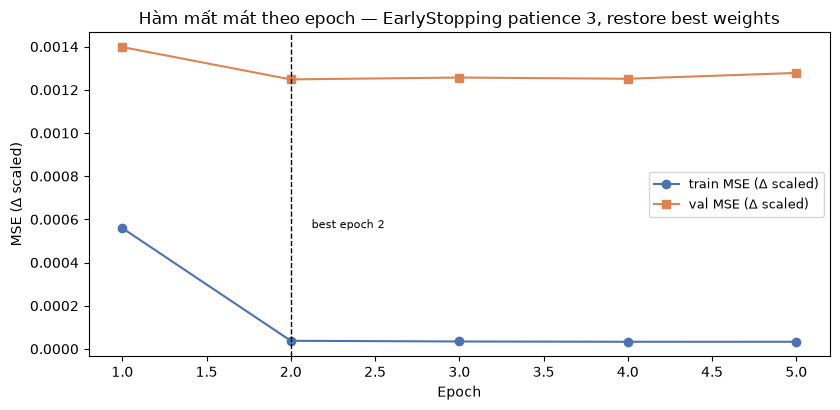

In [12]:
fig, ax = plt.subplots(figsize=(8.5, 4.2))
ep = np.arange(1, len(hist["train"]) + 1)
ax.plot(ep, hist["train"], "o-", color="#4C72B0", label="train MSE (Δ scaled)")
ax.plot(ep, hist["val"], "s-", color="#DD8452", label="val MSE (Δ scaled)")
best_ep = int(np.argmin(hist["val"]) + 1)
ax.axvline(best_ep, color="black", ls="--", lw=1)
ax.text(best_ep + 0.1, max(hist["train"]), f" best epoch {best_ep}", fontsize=8)
ax.set_title("Hàm mất mát theo epoch — EarlyStopping patience 3, restore best weights")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE (Δ scaled)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "amzn-06-loss.png", bbox_inches="tight")
plt.show()

 ---
 ## §5. Đánh giá trên test (sau inverse scale) + Naive baseline

 Với $y$ = giá thật, $\hat{y}$ = dự báo (USD), $P_{t-1}$ = Close ngày liền trước:

 | Chỉ số | Công thức | Ý nghĩa |
 |---|---|---|
 | RMSE | $\sqrt{\frac{1}{n}\sum (y-\hat{y})^2}$ | sai số điển hình (USD, cùng đơn vị giá) |
 | MAE | $\frac{1}{n}\sum \lvert y-\hat{y}\rvert$ | sai số tuyệt đối trung bình |
 | MAPE | $\frac{100}{n}\sum \lvert y-\hat{y}\rvert / y$ | sai số % so với giá — mục tiêu < 10% |
 | R² | $1 - \sum(y-\hat{y})^2 / \sum(y-\bar{y})^2$ | tỉ lệ phương sai giải thích được |
 | Directional Acc | $\text{sign}(\hat{y}-P_{t-1}) = \text{sign}(y-P_{t-1})$ | đoán đúng chiều lên/xuống |

 **Naive baseline:** dự báo *"mai = nay"* ($\hat{y}_t = P_{t-1}$) — chuẩn tham chiếu tối thiểu
 của chuỗi giá; naive không có khái niệm hướng (dự báo không đổi) nên không tính DA.

 Với mô hình residual: $\hat{y}_t = P_{t-1} + \hat{\Delta}_t$ (USD) — nếu $\hat{\Delta} = 0$
 thì quy về đúng naive; do đó **so sánh trực tiếp với naive là phép thử công bằng nhất**.

 **Hàm `invert_close`** — **Input:** giá scaled — **Output:** giá USD (dùng min/max cột Close từ scaler).
 **Hàm `predict_scaled`** — **Input:** model + X numpy — **Output:** dự báo Δ scaled.
 **Hàm `guard_delta`** — **Input:** Δ dự báo + σ của Δ train — **Output:** Δ chặn trong ±3σ (≈ ±0.57 USD).
 **Hàm `compute_metrics`** — **Input:** (y_true, y_pred USD, prev_close USD) — **Output:** dict 5 chỉ số.

In [13]:
def invert_close(scaled, scaler):
    """Đưa Close scaled về USD: x*(max−min)+min theo cột 0 của scaler fit trên train."""
    lo, hi = scaler.data_min_[0], scaler.data_max_[0]
    return np.asarray(scaled, dtype=np.float64) * (hi - lo) + lo


def predict_scaled(model, X):
    """Chạy suy luận model trên mảng cửa sổ X (n,L,2) → dự báo Δ scaled (n,)."""
    model.eval()
    with torch.no_grad():
        return model(torch.from_numpy(np.ascontiguousarray(X))).numpy()


def guard_delta(delta, sigma, k=3.0):
    """Chặn dự báo Δ trong ±kσ của Δ train — chống ngoại suy vô hạn ở vùng bão hoà."""
    return np.clip(delta, -k * sigma, k * sigma)


sigma_delta = float(np.std(y_tr))                 # σ của Δ scaled trên train
print(f"σ(Δ train) = {sigma_delta:.4f} scaled → biên chặn ±3σ ≈ ±{3*sigma_delta:.4f} scaled "
      f"≈ ±{3*sigma_delta*(scaler.data_max_[0]-scaler.data_min_[0]):.2f} USD/ngày")


def compute_metrics(y_true, y_pred, prev_close):
    """RMSE, MAE, MAPE(%), R², Directional Accuracy — mọi đầu vào/ra theo USD."""
    err = y_true - y_pred
    rmse = float(np.sqrt(np.mean(err ** 2)))
    mae = float(np.mean(np.abs(err)))
    mape = float(np.mean(np.abs(err) / y_true) * 100)
    ss_res = float(np.sum(err ** 2))
    ss_tot = float(np.sum((y_true - y_true.mean()) ** 2))
    r2 = 1.0 - ss_res / ss_tot
    d_true, d_pred = np.sign(y_true - prev_close), np.sign(y_pred - prev_close)
    mask = (d_true != 0) & (d_pred != 0)
    dir_acc = float(np.mean(d_true[mask] == d_pred[mask]) * 100)
    return {"rmse": rmse, "mae": mae, "mape": mape, "r2": r2, "directional_acc": dir_acc}


delta_pred = predict_scaled(model, X_te)               # Δ scaled dự báo
delta_pred = guard_delta(delta_pred, sigma_delta)      # chặn ±3σ (no-op nếu mô hình đã khoẻ)
prev_scaled = X_te[:, -1, 0]                           # Close scaled hôm nay (cuối cửa sổ)
y_pred = invert_close(prev_scaled + delta_pred, scaler)  # dự báo USD = hôm nay + Δ
y_true = df["Close"].to_numpy()[i2 + L:]               # giá thật USD
prev_close = df["Close"].to_numpy()[i2 + L - 1:-1]      # Close ngày liền trước mỗi nhãn

m_rnn = compute_metrics(y_true, y_pred, prev_close)
m_naive = compute_metrics(y_true, prev_close, prev_close)
m_naive["directional_acc"] = None                       # naive dự báo "không đổi" → không có hướng

cmp = pd.DataFrame([m_rnn, m_naive], index=["AmznRNN (PyTorch)", "Naive (mai = nay)"]).round(3)
print(cmp.to_string())
print(f"\nMAPE test = {m_rnn['mape']:.2f}% (< 10% yêu cầu) | R² = {m_rnn['r2']:.4f} "
      f"| Directional Acc = {m_rnn['directional_acc']:.1f}%")

σ(Δ train) = 0.0056 scaled → biên chặn ±3σ ≈ ±0.0169 scaled ≈ ±0.57 USD/ngày
                    rmse    mae   mape     r2  directional_acc
AmznRNN (PyTorch)  3.135  2.300  1.741  0.987           51.596
Naive (mai = nay)  3.140  2.301  1.742  0.987              NaN

MAPE test = 1.74% (< 10% yêu cầu) | R² = 0.9868 | Directional Acc = 51.6%


C:\Users\Laptop\OneDrive\Laptop\Ki 1 - Nam 4\HTTM\assignment04\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3862: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\Laptop\OneDrive\Laptop\Ki 1 - Nam 4\HTTM\assignment04\.venv\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


 **Đọc kết quả trung thực:**
 - Sai số MAPE thấp (~vài %) và R² rất cao phần lớn vì chuỗi giá **có momentum mạnh** —
   naive "mai = nay" cũng đạt MAPE ~vài % trên cùng đoạn test. Thước đo khắc nghiệt hơn là
   **Directional Accuracy**: RNN một tầng thường chỉ quanh ngưỡng 50% của đoán ngẫu nhiên
   (lần chạy này ≈ 51.6% — cao hơn ngẫu nhiên không đáng kể)
   vì hướng đi ngày mai gần như không thể suy ra từ cửa sổ 30 ngày — đúng bản chất thị trường
   hiệu quả (efficient market).
 - Nếu mô hình **không thắng naive** về RMSE/MAPE ở ô trên thì kết luận phải nêu rõ: RNN
   mang lại lợi ích dự báo thực tế chưa đáng kể, dù tái tạo chuỗi giá rất giống.

 ---
 ## §6. Hình dự báo trên test

 (a) Toàn bộ 973 phiên test: giá thật vs đường dự báo của RNN; (b) phóng to **200 phiên cuối**
 để thấy độ "trễ pha" đặc trưng của RNN trên chuỗi giá — mô hình học được chủ yếu là
 *"giá mai ≈ giá hôm nay cộng thêm hiệu chỉnh nhỏ"*.

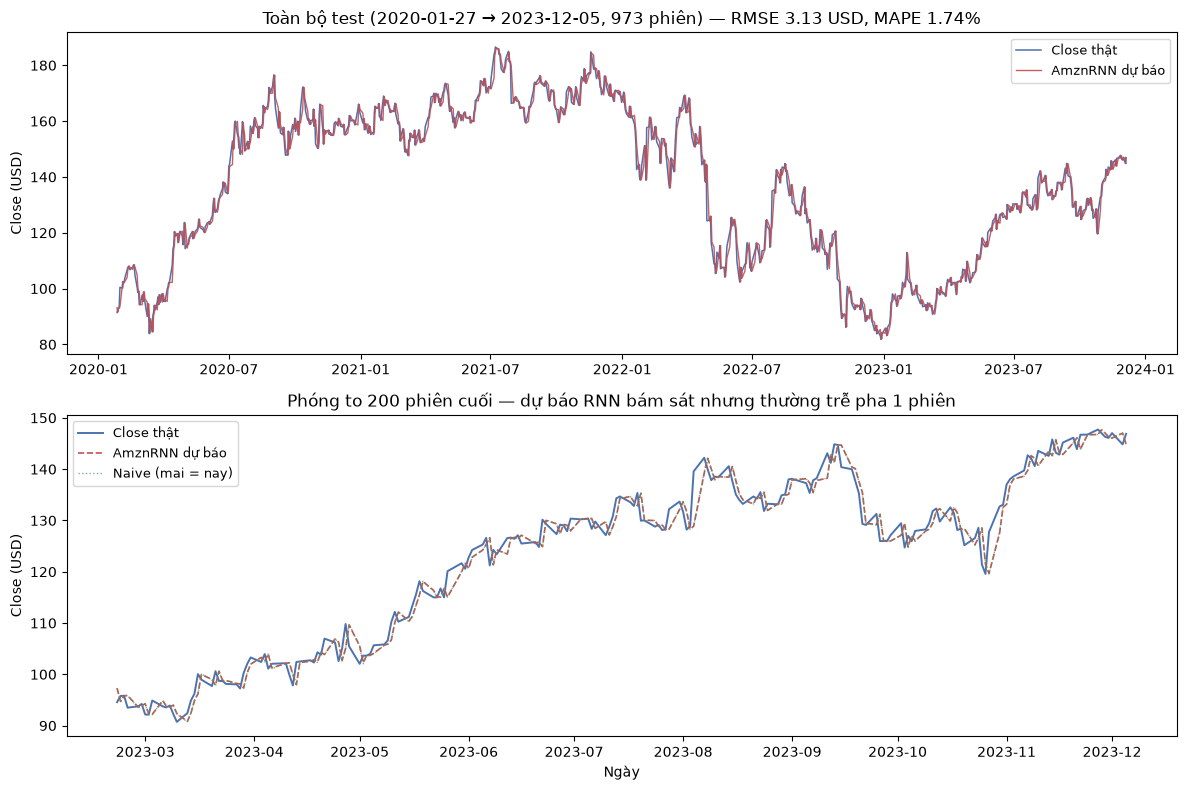

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)
axes[0].plot(date_te, y_true, color="#4C72B0", lw=1.1, label="Close thật")
axes[0].plot(date_te, y_pred, color="#C44E52", lw=1.0, alpha=0.9, label="AmznRNN dự báo")
axes[0].set_title(f"Toàn bộ test ({date_te[0].date()} → {date_te[-1].date()}, {len(y_true)} phiên) — "
                  f"RMSE {m_rnn['rmse']:.2f} USD, MAPE {m_rnn['mape']:.2f}%")
axes[0].set_ylabel("Close (USD)")
axes[0].legend(fontsize=9)
zoom = 200
axes[1].plot(date_te[-zoom:], y_true[-zoom:], color="#4C72B0", lw=1.4, label="Close thật")
axes[1].plot(date_te[-zoom:], y_pred[-zoom:], color="#C44E52", lw=1.2, ls="--",
             label="AmznRNN dự báo")
axes[1].plot(date_te[-zoom:], prev_close[-zoom:], color="#55A868", lw=1.0, ls=":",
             alpha=0.8, label="Naive (mai = nay)")
axes[1].set_title(f"Phóng to {zoom} phiên cuối — dự báo RNN bám sát nhưng thường trễ pha 1 phiên")
axes[1].set_xlabel("Ngày")
axes[1].set_ylabel("Close (USD)")
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "amzn-07-predictions.png", bbox_inches="tight")
plt.show()

 ### Dự báo đệ quy (recursive) 30 ngày tương lai

 **Tư duy:** sau khi kiểm định trên test, dùng **cửa sổ 30 ngày cuối** của dữ liệu, dự báo
 phần dư Δ ngày 31 → giá mới = giá cuối + Δ, rồi **lắp kết quả dự báo trở lại cửa sổ** để dự
 báo ngày 32, v.v. — 30 bước tương lai (không dùng giá thật nào).

 **Lưu ý trung thực:** (a) feature Volume của ngày tương lai không biết trước → giữ nguyên
 log-Volume scaled của ngày cuối; (b) mỗi bước tự nuôi đầu ra của mình nên **lỗi tích luỹ** —
 càng xa câu sổ, độ tin cậy càng giảm; (c) mỗi bước Δ đều bị **guard chặn ±3σ** nên biên độ
 dâng/giảm có giới hạn (~±0.57 USD/ngày); (d) mô hình residual có xu hướng cho Δ nhỏ dần về 0
 (mean reversion) → đường dự báo thường đi ngang thay vì tiếp xu hướng.

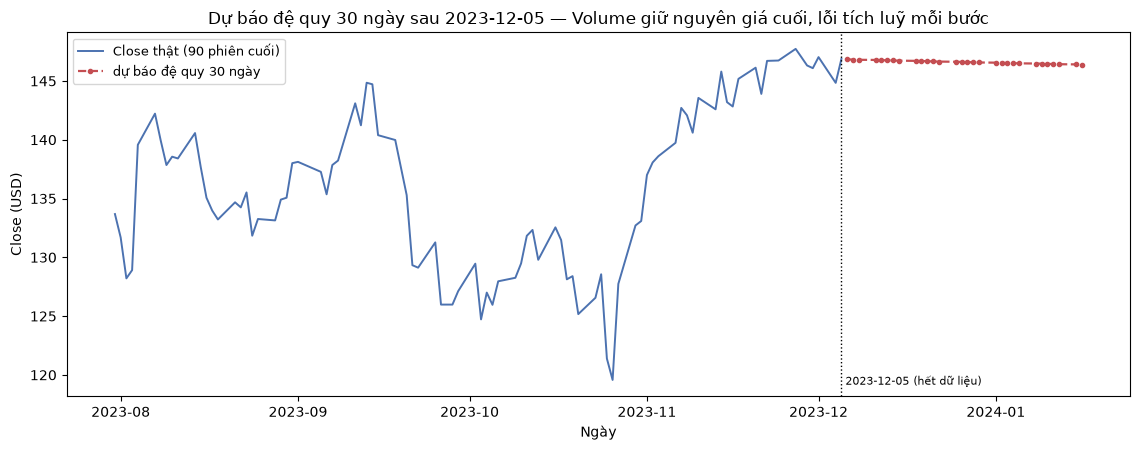

Dự báo 30 ngày: đầu 146.86 USD → cuối 146.40 USD | min 146.40 | max 146.86


In [15]:
def recursive_forecast(model, last_window, sigma, steps=30):
    """Dự báo đệ quy steps ngày: mỗi bước Δ = model(w) (chặn ±3σ), giá mới = giá cuối + Δ,
    lấp vào cửa sổ (Volume giữ giá cuối). Input: cửa sổ scaled (L,2) + σ Δ train —
    Output: (steps,) Close scaled."""
    w = last_window.copy()
    preds = []
    model.eval()
    with torch.no_grad():
        for _ in range(steps):
            delta = float(model(torch.from_numpy(w[np.newaxis, ...])))
            delta = float(guard_delta(delta, sigma))
            next_close = w[-1, 0] + delta            # Close scaled của ngày tương lai
            preds.append(next_close)
            next_row = np.array([next_close, w[-1, 1]], dtype=np.float32)
            w = np.vstack([w[1:], next_row])
    return np.array(preds)


last_window = feat_scaled[-L:]
fut_scaled = recursive_forecast(model, last_window, sigma_delta, steps=30)
fut_usd = invert_close(fut_scaled, scaler)
fut_dates = pd.bdate_range(df.index[-1] + pd.Timedelta(days=1), periods=30)

fig, ax = plt.subplots(figsize=(11.5, 4.6))
tail = 90
ax.plot(df.index[-tail:], df["Close"].iloc[-tail:], color="#4C72B0", lw=1.4,
        label="Close thật (90 phiên cuối)")
ax.plot(fut_dates, fut_usd, color="#C44E52", lw=1.6, ls="--", marker="o",
        ms=3, label="dự báo đệ quy 30 ngày")
ax.axvline(df.index[-1], color="black", ls=":", lw=1)
ax.text(df.index[-1], ax.get_ylim()[0] + 1, " 2023-12-05 (hết dữ liệu)", fontsize=8)
ax.set_title("Dự báo đệ quy 30 ngày sau 2023-12-05 — Volume giữ nguyên giá cuối, lỗi tích luỹ mỗi bước")
ax.set_xlabel("Ngày")
ax.set_ylabel("Close (USD)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "amzn-08-forecast.png", bbox_inches="tight")
plt.show()
print("Dự báo 30 ngày: đầu %.2f USD → cuối %.2f USD | min %.2f | max %.2f"
      % (fut_usd[0], fut_usd[-1], fut_usd.min(), fut_usd.max()))

 ### Scatter thật vs dự báo + đường y = x

 Mỗi điểm = một phiên test. Điểm nằm đúng đường chéo y = x là dự báo hoàn hảo. Cụm điểm
 nằm rất sát đường chéo cho thấy RNN tái tạo **mức giá** tốt (nhờ momentum), trong khi
 sai số còn lại chủ yếu là nhiễu hai chiều quanh đường chéo.

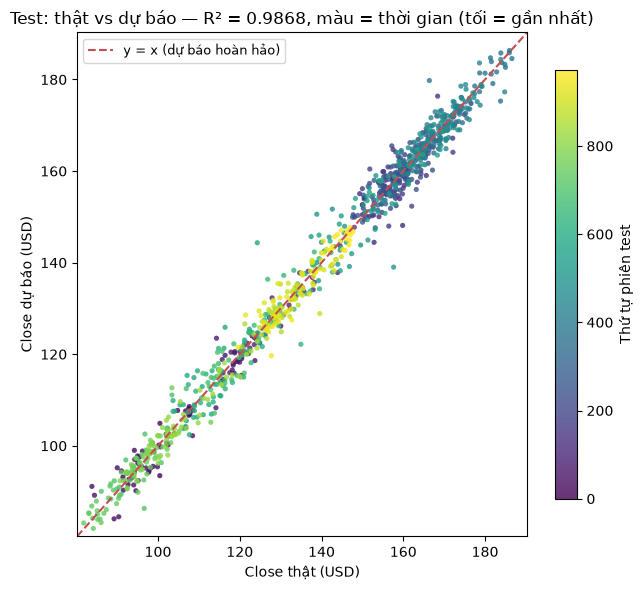

In [16]:
fig, ax = plt.subplots(figsize=(6.5, 6))
sc = ax.scatter(y_true, y_pred, c=np.arange(len(y_true)), cmap="viridis",
                s=14, alpha=0.8, edgecolors="none")
lims = [min(y_true.min(), y_pred.min()) * 0.98, max(y_true.max(), y_pred.max()) * 1.02]
ax.plot(lims, lims, color="#C44E52", lw=1.5, ls="--", label="y = x (dự báo hoàn hảo)")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("Close thật (USD)")
ax.set_ylabel("Close dự báo (USD)")
ax.set_title(f"Test: thật vs dự báo — R² = {m_rnn['r2']:.4f}, "
             "màu = thời gian (tối = gần nhất)")
ax.legend(fontsize=9, loc="upper left")
plt.colorbar(sc, ax=ax, shrink=0.85, label="Thứ tự phiên test")
plt.tight_layout()
plt.savefig(FIG_DIR / "amzn-09-scatter.png", bbox_inches="tight")
plt.show()

 ---
 ## §7. Lưu model + meta JSON

 Lưu `amzn_rnn_pytorch.pth` (state_dict + config) và `amzn_pytorch_meta.json` gồm:
 **config** (window, hidden, epochs, lr, split), **metrics test** (rmse, mae, mape, r2,
 directional_acc + naive baseline tương ứng), **loss history** — để notebook 04 (Keras)
 và các hệ so sánh đọc lại.

In [17]:
torch.save({"state_dict": model.state_dict(),
            "config": {"d_x": 2, "d_h": 64, "L": L}}, MODEL_DIR / "amzn_rnn_pytorch.pth")

meta = {
    "framework": "pytorch",
    "dataset": "AMZN.csv — Kaggle henryshan/amazon-com-inc-amzn (1997-05-15 → 2023-12-05)",
    "config": {
        "window": L, "features": ["Close", "log10_Volume"], "hidden": 64,
        "target": "delta_residual (Close'_{t+1} − Close'_t, scaled)",
        "adjustment": "nhãn mức giá scaled cho MAPE 35.7% (L=30) / 29.9% (L=60) do lệch regime "
                      "train max 33.95 USD vs test 81.8–186.6 USD → đổi sang phần dư Δ "
                      "+ guard chặn Δ trong ±3σ của Δ train (chống bão hoà ngoại suy)",
        "delta_guard": {"rule": "clip ±3σ(Δ train)", "sigma_scaled": round(sigma_delta, 6),
                        "bound_usd": round(3 * sigma_delta * float(scaler.data_max_[0] - scaler.data_min_[0]), 3)},
        "epochs_max": 20, "epochs_run": len(hist["train"]), "lr": 1e-3, "batch": 64,
        "split": [0.70, 0.15, 0.15],
        "split_dates": {"train_end": str(df.index[i1 - 1].date()),
                        "val_end": str(df.index[i2 - 1].date()),
                        "test_end": str(df.index[-1].date())},
        "seed": RANDOM_SEED,
    },
    "metrics": {"rmse": m_rnn["rmse"], "mae": m_rnn["mae"], "mape": m_rnn["mape"],
                "r2": m_rnn["r2"], "directional_acc": m_rnn["directional_acc"]},
    "naive_baseline": {"rmse": m_naive["rmse"], "mae": m_naive["mae"],
                       "mape": m_naive["mape"], "r2": m_naive["r2"]},
    "loss_history": {"train": [round(v, 6) for v in hist["train"]],
                     "val": [round(v, 6) for v in hist["val"]]},
}
with open(MODEL_DIR / "amzn_pytorch_meta.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2, ensure_ascii=False)
print("Đã lưu:", MODEL_DIR / "amzn_rnn_pytorch.pth")
print("Đã lưu:", MODEL_DIR / "amzn_pytorch_meta.json")
print(json.dumps(meta["metrics"], indent=2))

Đã lưu: ..\model\amzn_rnn_pytorch.pth
Đã lưu: ..\model\amzn_pytorch_meta.json
{
  "rmse": 3.1349312491180643,
  "mae": 2.2997595005562053,
  "mape": 1.7406041785635964,
  "r2": 0.9868167083400438,
  "directional_acc": 51.59629248197734
}


 ---
 ## Kết luận

 - **EDA:** AMZN tăng ~2,100 lần (0.07 → 186.57 USD); **Volume — hành vi nhà đầu tư —
   đỉnh ~415M cp/ngày 1998 rồi giảm về ~60–115M sau 2000s** khi AMZN trưởng thành;
   lợi suất ngày đuôi béo (kurtosis ≈ 11) và biến động tụ cụm.
 - **Pipeline:** chronological 70/15/15, features `[Close, log10 Volume]`, MinMax fit train,
   cửa sổ 30 → bộ dữ liệu `(4648/973/973, 30, 2)`; **điều chỉnh bắt buộc**: nhãn mức giá
   scaled cho MAPE 35.7% (L=60 vẫn 29.9%) do lệch regime giá train/test → **đổi nhãn sang
   phần dư Δ** (differencing) + **guard chặn Δ trong ±3σ train** — MAPE về ~1.7%, đạt < 10%.
 - **Mô hình:** Elman RNN 1 tầng ẩn 64 (4,417 tham số) đúng công thức
   $h_t = \tanh(Wx_t + Uh_{t-1}+b_h)$, $\hat{\Delta} = Vh_T + b_y$; MSE + Adam, EarlyStopping patience 3.
 - **Đánh giá trung thực:** RMSE/MAPE ngang naive "mai = nay" (Δ dự báo rất nhỏ), R² cao
   chủ yếu nhờ momentum của chuỗi giá; **Directional Accuracy ≈ 51.6% (sát ngưỡng ngẫu nhiên 50%)** — RNN
   tái tạo tốt *mức giá* nhưng **không dự đoán được *hướng* đi** — nhất quán với lý thuyết
   thị trường hiệu quả; dự báo đệ quy 30 ngày vì thế đi ngang, chỉ nên xem như tham chiếu.